In [84]:
suppressMessages({
    library(dplyr)
    library(tidyr)
    library(RNetCDF)
    library(ggplot2)
    library(hydroGOF)
    library(purrr)
    library(jsonlite)
    library(lubridate)
    library(ggh4x)
                  })

In [85]:
source('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/make_stat_df.R')
source('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/read_busboi.R')

In [86]:
# SVS_Q=SVS_in$Q
# SVS_reach_id=SVS_in$reach_id_v17[1,]
# SVS_date=SVS_in$date_ymd
# SVS_datetime=make_datetime(SVS_date[,1], SVS_date[,2], SVS_date[,3])

# remove=which(SVS_reach_id=="")

# SVS_df=data.frame(SVS_Q)%>%
#     mutate(date=as.Date(SVS_datetime))
# names(SVS_df)=c(SVS_reach_id,'date')

# SVS_df=SVS_df[,-remove]

# SVS=gather(SVS_df,reach_id,gauge_Q,-date)

# saveRDS(SVS,'/nas/cee-water/cjgleason/colin/analyze confluence runs/SVS_df_versionD.rds')

In [87]:
SVS_df= readRDS('/nas/cee-water/cjgleason/colin/analyze confluence runs/SVS_df.rds')
#now, throw out the training gauges
training_IDs='/nas/cee-water/cjgleason/colin/analyze confluence runs/reachids_svs_gages_used_to_train.json'
training_df=data.frame(training_ID=as.character(fromJSON(training_IDs)))

SVS_df= filter(SVS_df,!(reach_id %in% training_df$training_ID))
SVS_reaches=unique(SVS_df$reach_id)

In [88]:
# busboi_Q1='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/TEST_FIXED_BED_RETRY/'
# busboi_Q1='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/monthly_b_then_Q/'
# busboi_Q2='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/daily_b_then_Q/'
# busboi_Q4='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/multiobj/'
busboi_Q1='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/monthly_single_splineD/'
# busboi_Q2='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/daily_versionD/'

busboi_Q2='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/daily_single_splineD/'


In [89]:
#read the SoS for comparison
run_base_path='/nas/cee-ice/data/Confluence_Runs/version 3_0_0'
SoS_dataframes=list.files(run_base_path,full.names=TRUE,pattern='confluence_3_0.rds')

#reduce ram
reductor=function(dataframe_in,SVS_reaches){
        #we only need to run at places with gauges
        confluence_with_gauge=readRDS(dataframe_in)%>%
            filter(reach_id %in% SVS_reaches)
    }

SoS_df=do.call(rbind,lapply(SoS_dataframes,reductor,SVS_reaches))

n_pairs=20

 source('/nas/cee-water/cjgleason/colin/analyze confluence runs/make_stat_df_fullrun.R')

confluence_v3=make_stat_df_fullrun(SoS_df,SVS_df,n_pairs) %>%
    mutate(ID='Confluence 3.0')


In [90]:
suppressWarnings({
    n_pairs=20
    busboi_monthly=read_busboi(busboi_Q1,SVS_df,n_pairs,'SVS')$stats%>%
        mutate(ID='Monthly prior BUSBOI')
        #get rid of OOM bias

    
    busboi_daily=read_busboi(busboi_Q2,SVS_df,n_pairs,'SVS')$stats%>%
        mutate(ID='Daily prior BUSBOI')

 
    # ml_ensemble_stats_SVS=make_stat_df_fullrun(ML_ensemble_Q,SVS_df,n_pairs) 
    
    })

In [91]:
   #get OOM prior bias
    biascheck=filter(busboi_daily,ID2=='prior')%>%
        filter(nbias<0.95)

matched_reaches=biascheck$reach_id
busboi_monthly=busboi_monthly%>%
    filter(reach_id %in% matched_reaches)

busboi_daily=busboi_daily%>%
    filter(reach_id %in% matched_reaches)

In [92]:
busboi1=unique(busboi_monthly$reach_id)
busboi2=unique(busboi_daily$reach_id)
confluence=unique(confluence_v3$reach_id)

gauges_in_common=Reduce(intersect, list(busboi1,busboi2,confluence))
length(gauges_in_common)
length(busboi1)
length(busboi2)


[1] 347

[1] 547

[1] 548

In [93]:
# plotter=rbind(busboi_stats_SVS,Confluence_v3_stats_SVS,busboi_daily_stats_SVS)%>% 
plotter=rbind(busboi_monthly,busboi_daily,confluence_v3)%>%
##toggle to make gauges in common ###
      filter(reach_id %in% gauges_in_common)%>%
        #recalculate n
            ungroup()%>%
            group_by(ID)%>%
            mutate(n=length(unique(reach_id)))%>%
            ungroup()%>%
###-------
         gather(stat,value,-reach_id,-ID,-ID2,-n)

Warning message:
“Removed 54 rows containing non-finite outside the scale range (`stat_ecdf()`).”
Warning message:
“Removed 54 rows containing non-finite outside the scale range (`stat_ecdf()`).”


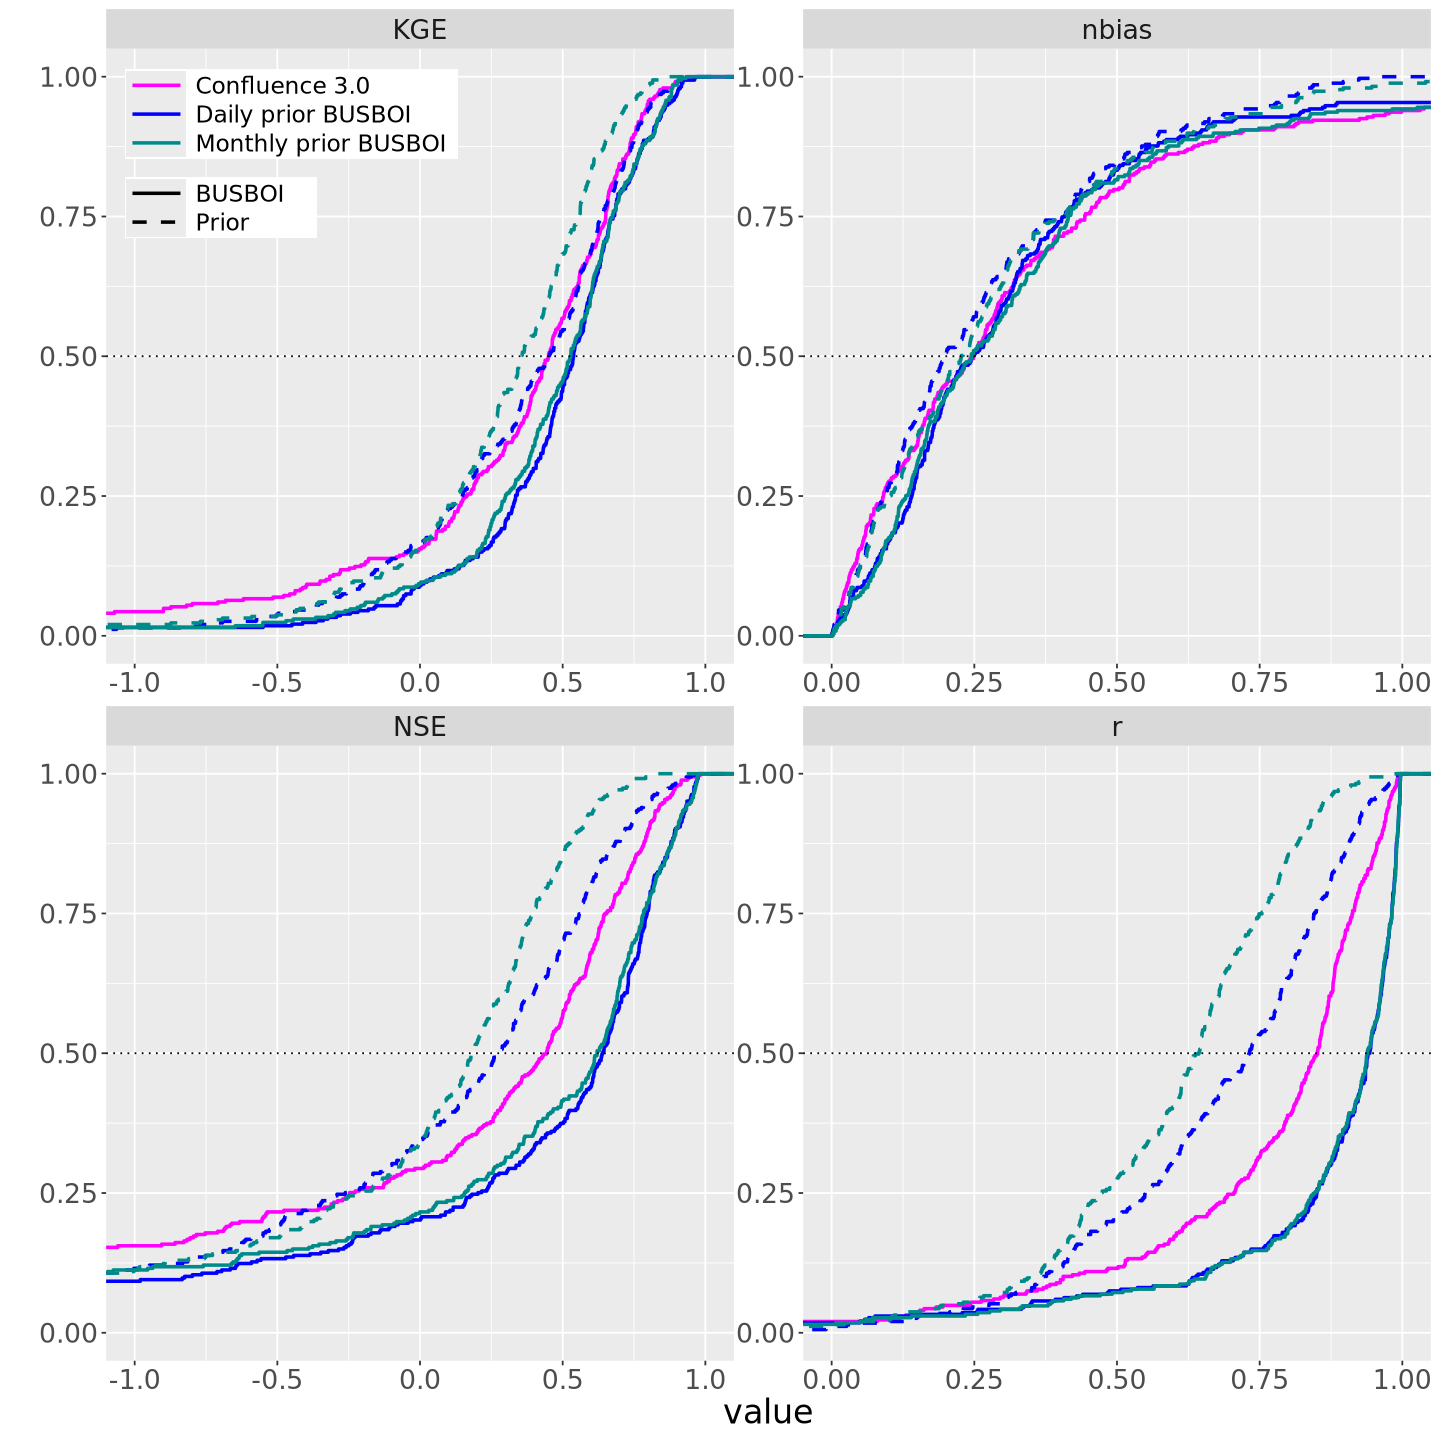

In [94]:
    suppressWarnings({
library(RColorBrewer)
palette = brewer.pal(length(unique(plotter$ID)), 'Dark2')
        palette=c('magenta','blue','dark cyan')

options(repr.plot.width = 12, repr.plot.height = 12)
p1= ggplot(plotter)+
        
    stat_ecdf(aes(x=value,col=ID,linetype=ID2), lwd=1)+ #
    # coord_cartesian(xlim=c(-1,1))+

    scale_linetype_manual(values=c('solid','dashed'),labels=c('BUSBOI','Prior'))+
    scale_colour_manual(values=palette[1:3])+
                        # labels=c('SWOT consensus v3','daily BUSBOI','monthly BUSBOI'))+
    # scale_colour_manual(labels='none')+
    ylab(' ')+
        
    # geom_hline(yintercept = 0.32, linetype = "dotted", color = "black") +
    geom_hline(yintercept = 0.50, linetype = "dotted", color = "black") +
    # geom_hline(yintercept = 0.68, linetype = "dotted", color = "black")  +
        
    theme(legend.position='inside bottom')+
    theme(text=element_text(size = 20))+
    theme(plot.title=element_text(size = 25))+
    theme(legend.position=c(0.14,0.92))+
    theme(legend.margin  = margin(1, 20, 1, 1))+
    theme(legend.text=element_text(size=14))+
    theme(legend.title = element_blank())+
    # # guides(color='none')+
    # guides(clor = guide_legend(override.aes = list(linetype = c("solid", "dashed"),
    #                                                color = c(palette[1], palette[2]))))+
         theme(legend.key.width = unit(2.5, "line"))

        

p1= p1+ facet_wrap(vars(stat),scales='free') +  
  facetted_pos_scales(
    x = list(
      stat == "KGE" ~ scale_x_continuous(limits = c(-1, 1)),
      stat == "NSE" ~ scale_x_continuous(limits = c(-1.0, 1.0)),
      stat == "r" ~ scale_x_continuous(limits = c(0, 1)),
      stat == "nbias" ~ scale_x_continuous(limits = c(0, 1.0))
    )
  )
    # geom_text( data    = dat_n,hjust=0,mapping = aes(x = x, y = y, label = label) )+
    # geom_text( data    = dat_text_32,hjust=0,mapping = aes(x = x, y = y, label = label) )+
    # geom_text( data    = dat_text_68,hjust=0,mapping = aes(x = x, y = y, label = label) ) +
    # geom_text( data    = dat_text_median,hjust=0,size=5,mapping = aes(x = x, y = y, label = label) )
    })

p1
ggsave('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/Figures/gauges_in_common.png', p1, 
       width = 12, 
       height = 12, 
       units = "in", dpi = 300)

# ggsave(,p1, width = 280, height = 220, units = "mm", dpi = 300)

In [95]:
# plotter=rbind(busboi_stats_SVS,Confluence_v3_stats_SVS,busboi_daily_stats_SVS)%>% 
plotter=rbind(busboi_monthly,busboi_daily)%>%
         gather(stat,value,-reach_id,-ID,-ID2,-n)

length(unique(plotter$reach_id))
      



[1] 548

Warning message:
“Removed 84 rows containing non-finite outside the scale range (`stat_ecdf()`).”
Warning message:
“Removed 84 rows containing non-finite outside the scale range (`stat_ecdf()`).”


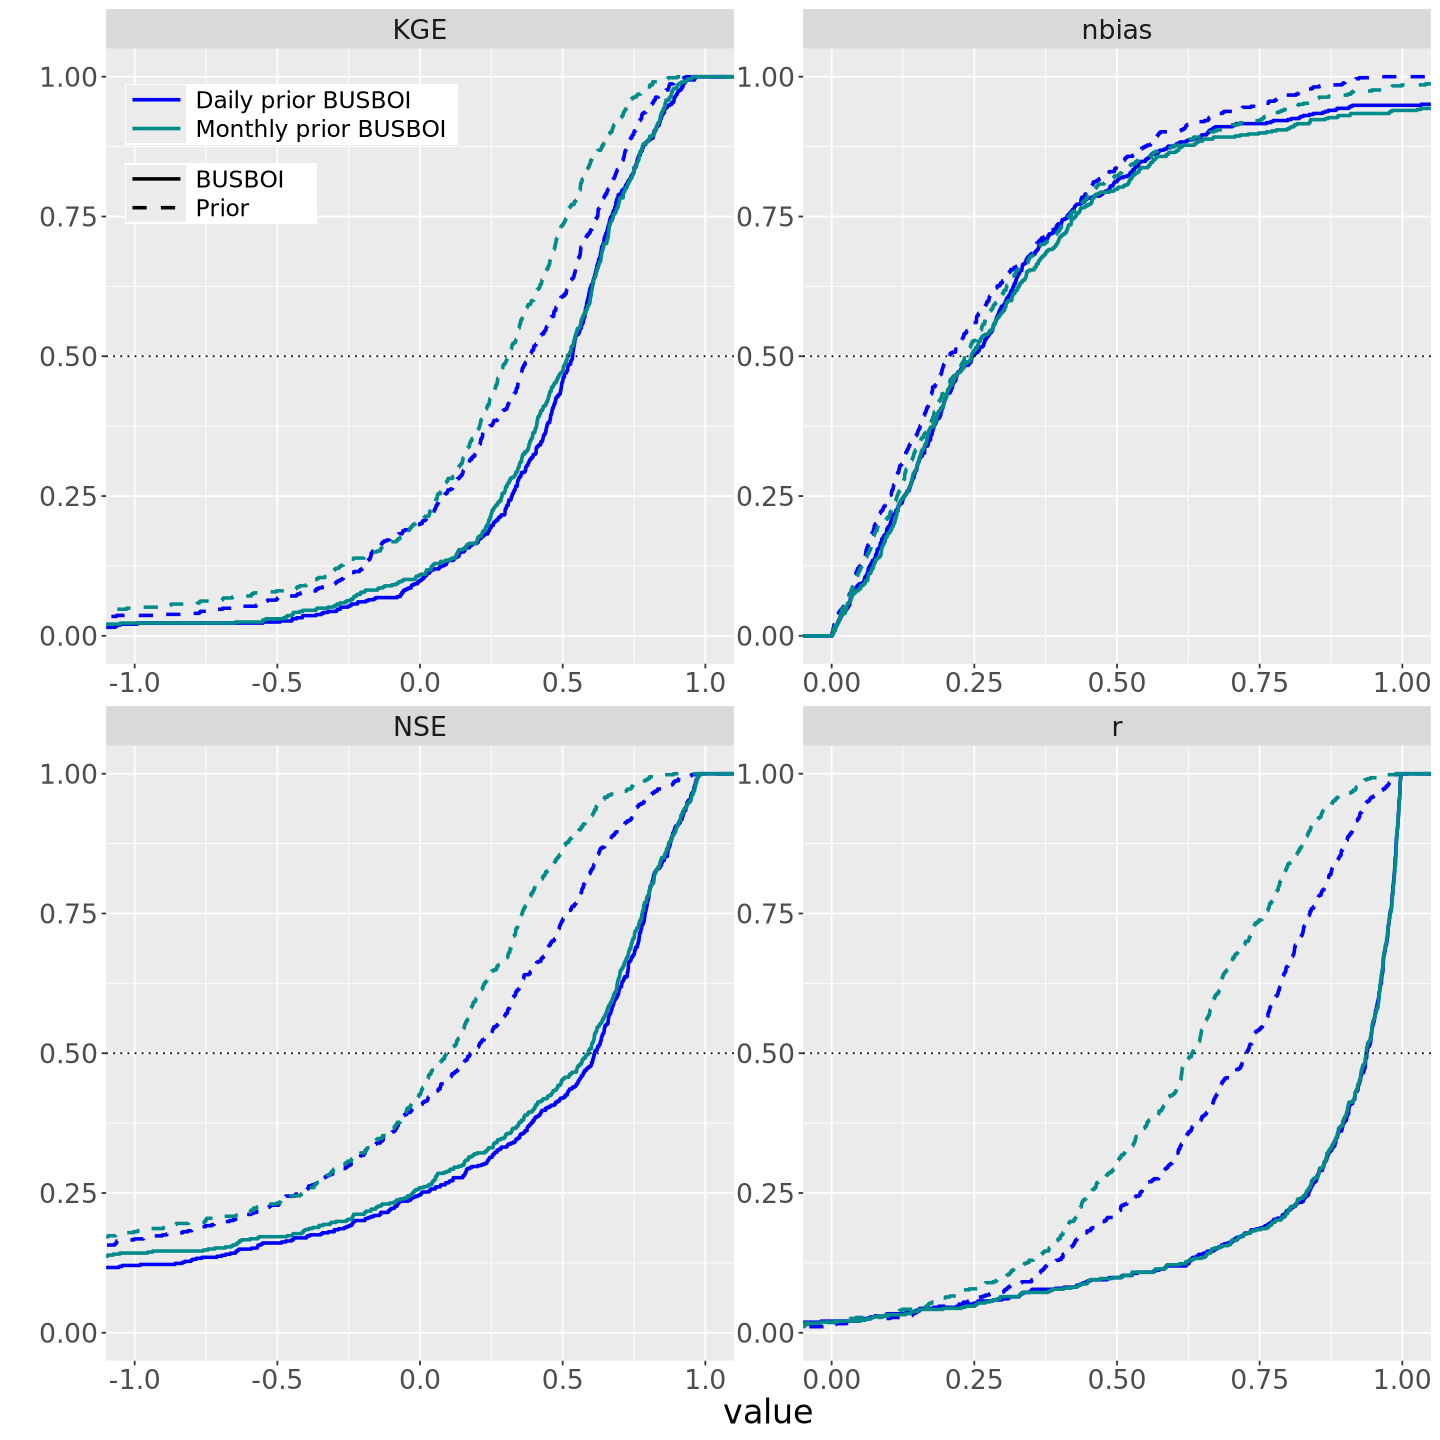

In [96]:
  suppressWarnings({
library(RColorBrewer)
palette = brewer.pal(length(unique(plotter$ID)), 'Dark2')
        palette=c('magenta','blue','dark cyan')

options(repr.plot.width = 12, repr.plot.height = 12)
p2= ggplot(plotter)+
        
    stat_ecdf(aes(x=value,col=ID,linetype=ID2), lwd=1)+ #
    # coord_cartesian(xlim=c(-1,1))+

    scale_linetype_manual(values=c('solid','dashed'),labels=c('BUSBOI','Prior'))+
    scale_colour_manual(values=palette[2:3])+
                        # labels=c('SWOT consensus v3','daily BUSBOI','monthly BUSBOI'))+
    # scale_colour_manual(labels='none')+
    ylab(' ')+
        
    # geom_hline(yintercept = 0.32, linetype = "dotted", color = "black") +
    geom_hline(yintercept = 0.50, linetype = "dotted", color = "black") +
    # geom_hline(yintercept = 0.68, linetype = "dotted", color = "black")  +
        
    theme(legend.position='inside bottom')+
    theme(text=element_text(size = 20))+
    theme(plot.title=element_text(size = 25))+
    theme(legend.position=c(0.14,0.92))+
    theme(legend.margin  = margin(1, 20, 1, 1))+
    theme(legend.text=element_text(size=14))+
    theme(legend.title = element_blank())+
    # # guides(color='none')+
    guides(clor = guide_legend(override.aes = list(linetype = c("solid", "dashed"),
                                                   color = c(palette[2], palette[3]))))+
         theme(legend.key.width = unit(2.5, "line"))

        

p2= p2+ facet_wrap(vars(stat),scales='free') +  
  facetted_pos_scales(
    x = list(
      stat == "KGE" ~ scale_x_continuous(limits = c(-1, 1)),
      stat == "NSE" ~ scale_x_continuous(limits = c(-1.0, 1.0)),
      stat == "r" ~ scale_x_continuous(limits = c(0, 1)),
      stat == "nbias" ~ scale_x_continuous(limits = c(0, 1.0))
    )
  )
    # geom_text( data    = dat_n,hjust=0,mapping = aes(x = x, y = y, label = label) )+
    # geom_text( data    = dat_text_32,hjust=0,mapping = aes(x = x, y = y, label = label) )+
    # geom_text( data    = dat_text_68,hjust=0,mapping = aes(x = x, y = y, label = label) ) +
    # geom_text( data    = dat_text_median,hjust=0,size=5,mapping = aes(x = x, y = y, label = label) )
    })
p2
ggsave('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/Figures/all_gauges.png', p2, 
       width = 12, 
       height = 12, 
       units = "in", dpi = 300)

# ggsave(,p1, width = 280, height = 220, units = "mm", dpi = 300)

In [97]:
busboi_Q3='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/monthly_b_then_Q/'
busboi_Q4='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/daily_b_then_Q/'

suppressWarnings({
 n_pairs=20
    busboi_monthly_C=read_busboi(busboi_Q3,SVS_df,n_pairs,'SVS')$stats%>%
        mutate(ID='Monthly prior BUSBOI vC')
    busboi_daily_C=read_busboi(busboi_Q4,SVS_df,n_pairs,'SVS')$stats%>%
        mutate(ID='Daily prior BUSBOI vC')

    })

busboi3=unique(busboi_monthly_C$reach_id)
busboi4=unique(busboi_daily_C$reach_id)


gauges_in_common2=Reduce(intersect, list(busboi1,busboi2,busboi3,busboi4))


In [98]:
# plotter=rbind(busboi_stats_SVS,Confluence_v3_stats_SVS,busboi_daily_stats_SVS)%>% 
plotter=rbind(busboi_daily,busboi_monthly,busboi_daily_C,busboi_monthly_C)%>%
      
      filter(reach_id %in% gauges_in_common2)%>%
        #recalculate n
            ungroup()%>%
            group_by(ID)%>%
            mutate(n=length(unique(reach_id)))%>%
            ungroup()%>%
            gather(stat,value,-reach_id,-ID,-ID2,-n)

length(unique(plotter$reach_id))
    

[1] 292

In [99]:
unique(plotter$ID)

[1] "Daily prior BUSBOI"      "Monthly prior BUSBOI"   
[3] "Daily prior BUSBOI vC"   "Monthly prior BUSBOI vC"

Warning message:
“Removed 118 rows containing non-finite outside the scale range (`stat_ecdf()`).”


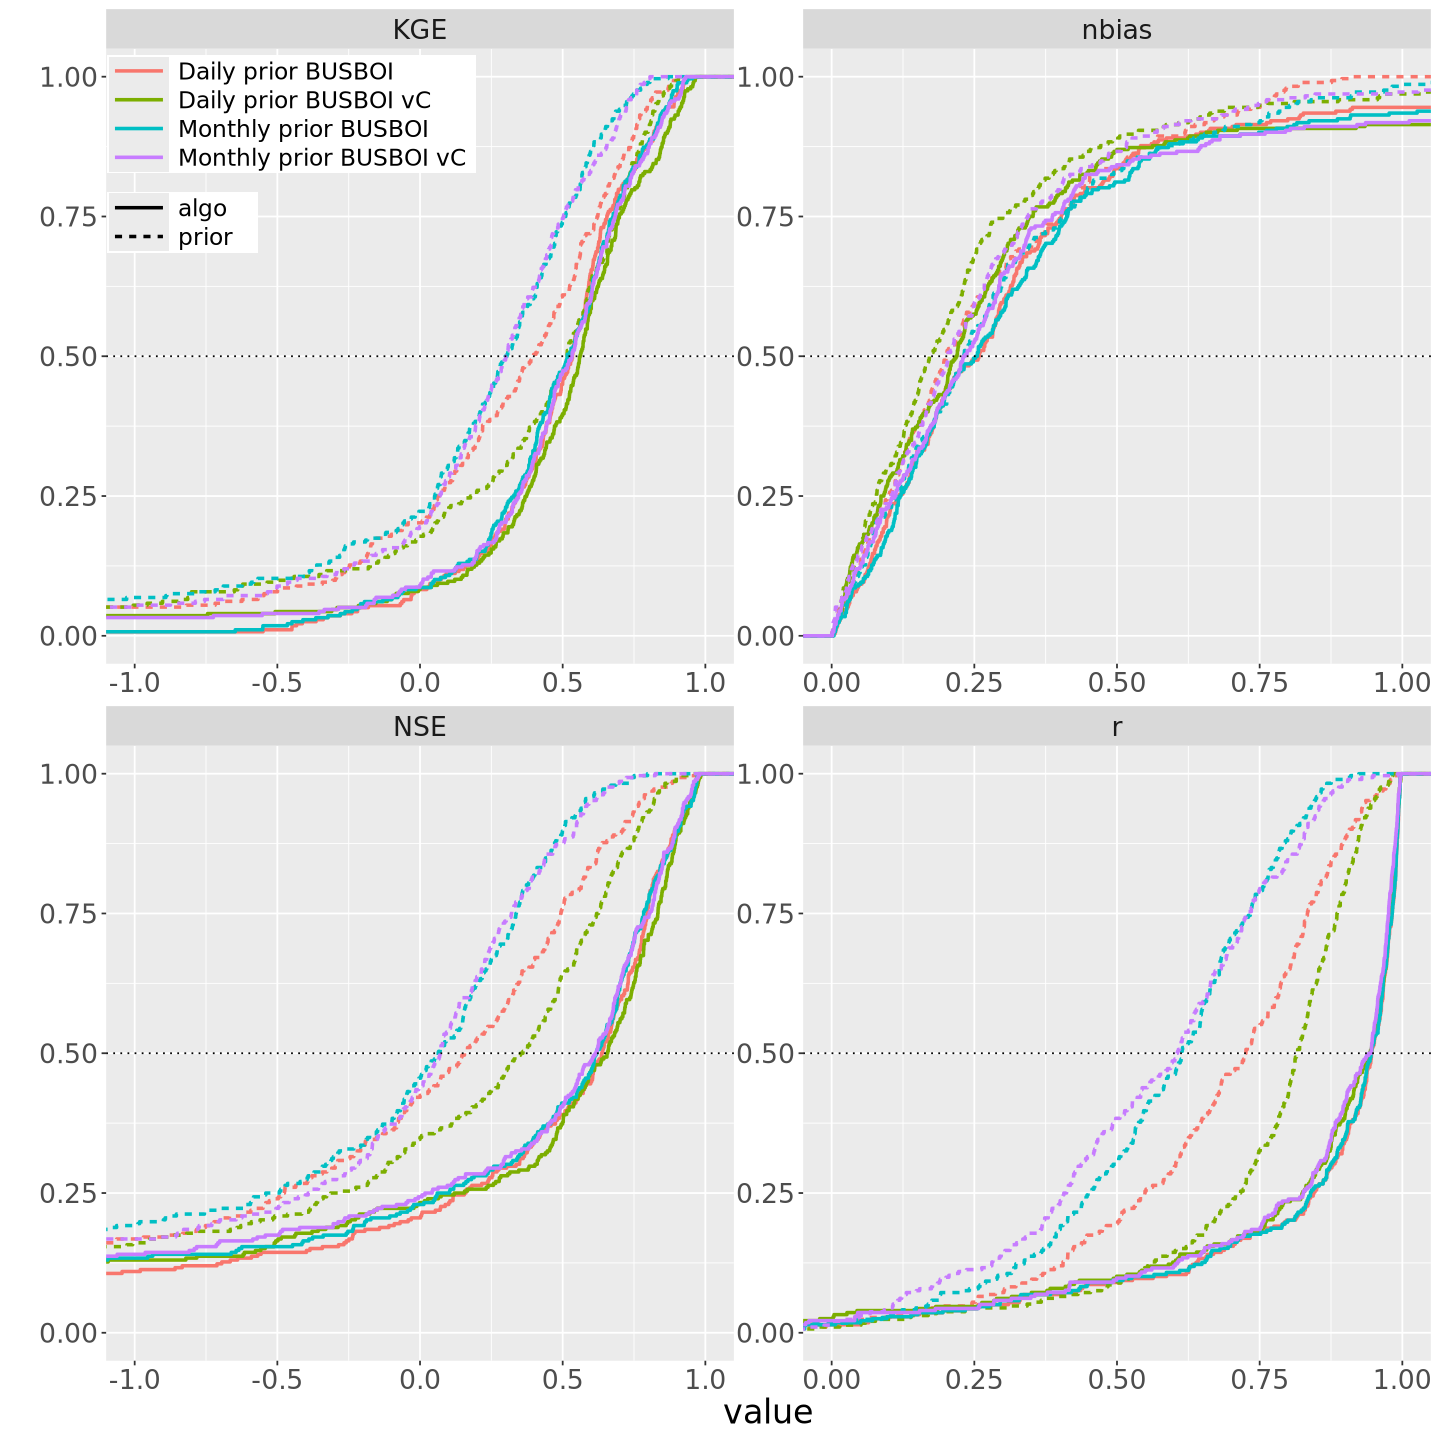

In [100]:
  suppressWarnings({
library(RColorBrewer)
palette = brewer.pal(length(unique(plotter$ID)), 'Dark2')
        palette=c('magenta','blue','dark cyan')

options(repr.plot.width = 12, repr.plot.height = 12)
p2= ggplot(plotter)+
        
    stat_ecdf(aes(x=value,col=ID,linetype=ID2), lwd=1)+ #
    # coord_cartesian(xlim=c(-1,1))+

    # scale_linetype_manual(values=c('solid','dashed'),labels=c('BUSBOI','Prior'))+
    # scale_colour_manual(values=palette[1:3])+
                        # labels=c('SWOT consensus v3','daily BUSBOI','monthly BUSBOI'))+
    # scale_colour_manual(labels='none')+
    ylab(' ')+
        
    # geom_hline(yintercept = 0.32, linetype = "dotted", color = "black") +
    geom_hline(yintercept = 0.50, linetype = "dotted", color = "black") +
    # geom_hline(yintercept = 0.68, linetype = "dotted", color = "black")  +
        
    theme(legend.position='inside bottom')+
    theme(text=element_text(size = 20))+
    theme(plot.title=element_text(size = 25))+
    theme(legend.position=c(0.14,0.92))+
    theme(legend.margin  = margin(1, 20, 1, 1))+
    theme(legend.text=element_text(size=14))+
    theme(legend.title = element_blank())+
    # # guides(color='none')+
    # guides(clor = guide_legend(override.aes = list(linetype = c("solid", "dashed"),
    #                                                color = c(palette[1], palette[2]))))+
         theme(legend.key.width = unit(2.5, "line"))

        

p2= p2+ facet_wrap(vars(stat),scales='free') +  
  facetted_pos_scales(
    x = list(
      stat == "KGE" ~ scale_x_continuous(limits = c(-1, 1)),
      stat == "NSE" ~ scale_x_continuous(limits = c(-1.0, 1.0)),
      stat == "r" ~ scale_x_continuous(limits = c(0, 1)),
      stat == "nbias" ~ scale_x_continuous(limits = c(0, 1.0))
    )
  )
    # geom_text( data    = dat_n,hjust=0,mapping = aes(x = x, y = y, label = label) )+
    # geom_text( data    = dat_text_32,hjust=0,mapping = aes(x = x, y = y, label = label) )+
    # geom_text( data    = dat_text_68,hjust=0,mapping = aes(x = x, y = y, label = label) ) +
    # geom_text( data    = dat_text_median,hjust=0,size=5,mapping = aes(x = x, y = y, label = label) )
    })
p2
# ggsave('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/Figures/C_vs_D.png', p2, 
#        width = 12, 
#        height = 12, 
#        units = "in", dpi = 300)

# ggsave(,p1, width = 280, height = 220, units = "mm", dpi = 300)

NULL

Warning message:
“Removed 95 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 68 rows containing missing values or values outside the scale range
(`geom_line()`).”
Saving 7 x 7 in image


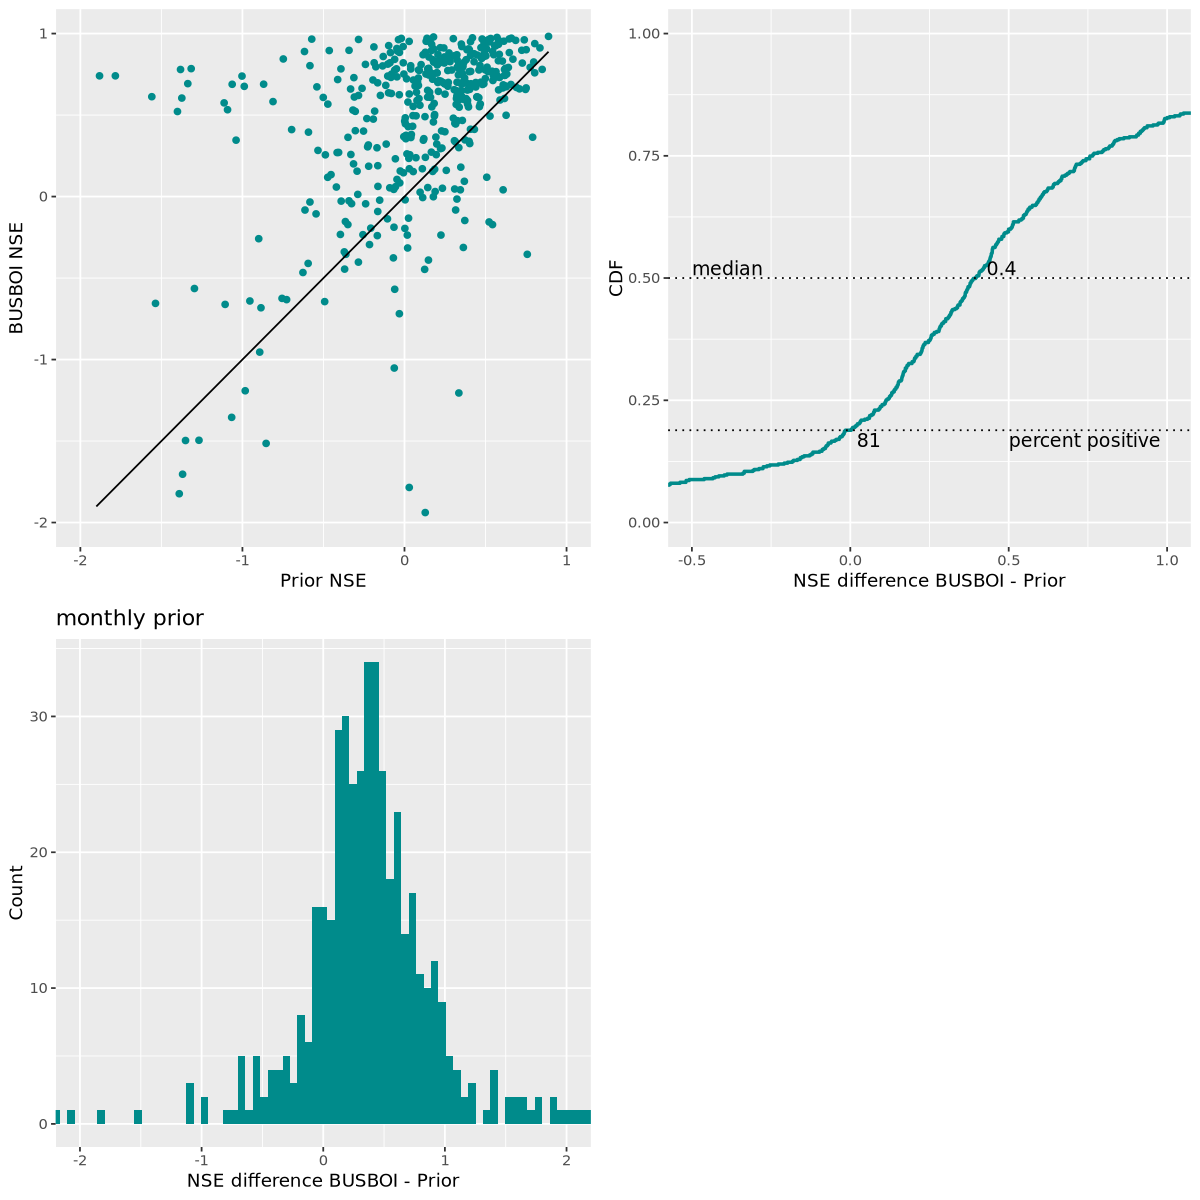

In [101]:
prior=filter(busboi_monthly,ID2=='prior')%>%
    transmute(reach_id=reach_id,prior_NSE=NSE)
algo=filter(busboi_monthly,ID2=='algo')%>%
    transmute(reach_id=reach_id,algo_NSE=NSE)
difference=left_join(prior,algo,by='reach_id')%>%
    mutate(delta_NSE=algo_NSE-prior_NSE)%>%
    filter(algo_NSE>-100)
p3=ggplot(difference)+
    geom_point(aes(x=prior_NSE,y=algo_NSE))+
    geom_line(aes(x=prior_NSE,y=prior_NSE),col='red')+
    xlim(c(-15,1))+
    ylim(c(-15,1))

p4=ggplot(difference)+
    geom_point(aes(x=prior_NSE,y=algo_NSE),col=palette[3])+
    geom_line(aes(x=prior_NSE,y=prior_NSE),col='black')+
    xlim(c(-2,1))+
    ylim(c(-2,1))+
    labs(x= 'Prior NSE')+
    labs(y= 'BUSBOI NSE')

#caclulate percent positive, 1- for CDF
percPos= 1-(sum(difference$delta_NSE >0) /length(difference$delta_NSE))

p5=ggplot(difference)+
    stat_ecdf(aes(x=delta_NSE),lwd=1,col=palette[3])+
  coord_cartesian(xlim=c(-0.5,1))+
    labs(x= 'NSE difference BUSBOI - Prior')+
    labs(y= 'CDF')+
    # annotate("text",hjust=0, x = 0.03+round(quantile(difference$delta_NSE,probs=0.32),digits=2), y = 0.34, label = round(quantile(difference$delta_NSE,probs=0.32),digits=2),
    #          size = 4)+
    annotate("text",hjust=0, x = 0.03+round(quantile(difference$delta_NSE,probs=0.50),digits=2), 
             y = 0.52, label = round(quantile(difference$delta_NSE,probs=0.50),digits=2),
             size = 4)+

    annotate("text",hjust=0, x = -0.5, y = 0.52, label ='median',
             size = 4)+
    annotate("text",hjust=0, x = 0.02, y = percPos-0.02, label =100*( 1-round(percPos,digits=2)),
             size = 4)+
   annotate("text",hjust=0, x =0.5 , y = percPos-0.02, label = 'percent positive',
             size = 4)+
    # geom_hline(yintercept = 0.32, linetype = "dotted", color = "black") +
    geom_hline(yintercept = 0.50, linetype = "dotted", color = "black") +
    geom_hline(yintercept = percPos, linetype = "dotted", color = "black") 

p6=ggplot(difference)+
    geom_histogram(aes(x=delta_NSE),bins=6000,fill=palette[3])+
    coord_cartesian(xlim=c(-2,2))+
    labs(x= 'NSE difference BUSBOI - Prior')+
    labs(y= 'Count')+
    ggtitle('monthly prior')

library(gridExtra)

options(repr.plot.width =10, repr.plot.height = 10)
suppressWarnings({

    })
# p6
# p4
# p5

test=grid.arrange(p4, p5, p6,nrow = 2)
ggsave('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/Figures/monthly_improvement.png',test)

NULL

Warning message:
“Removed 87 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 55 rows containing missing values or values outside the scale range
(`geom_line()`).”
Saving 7 x 7 in image


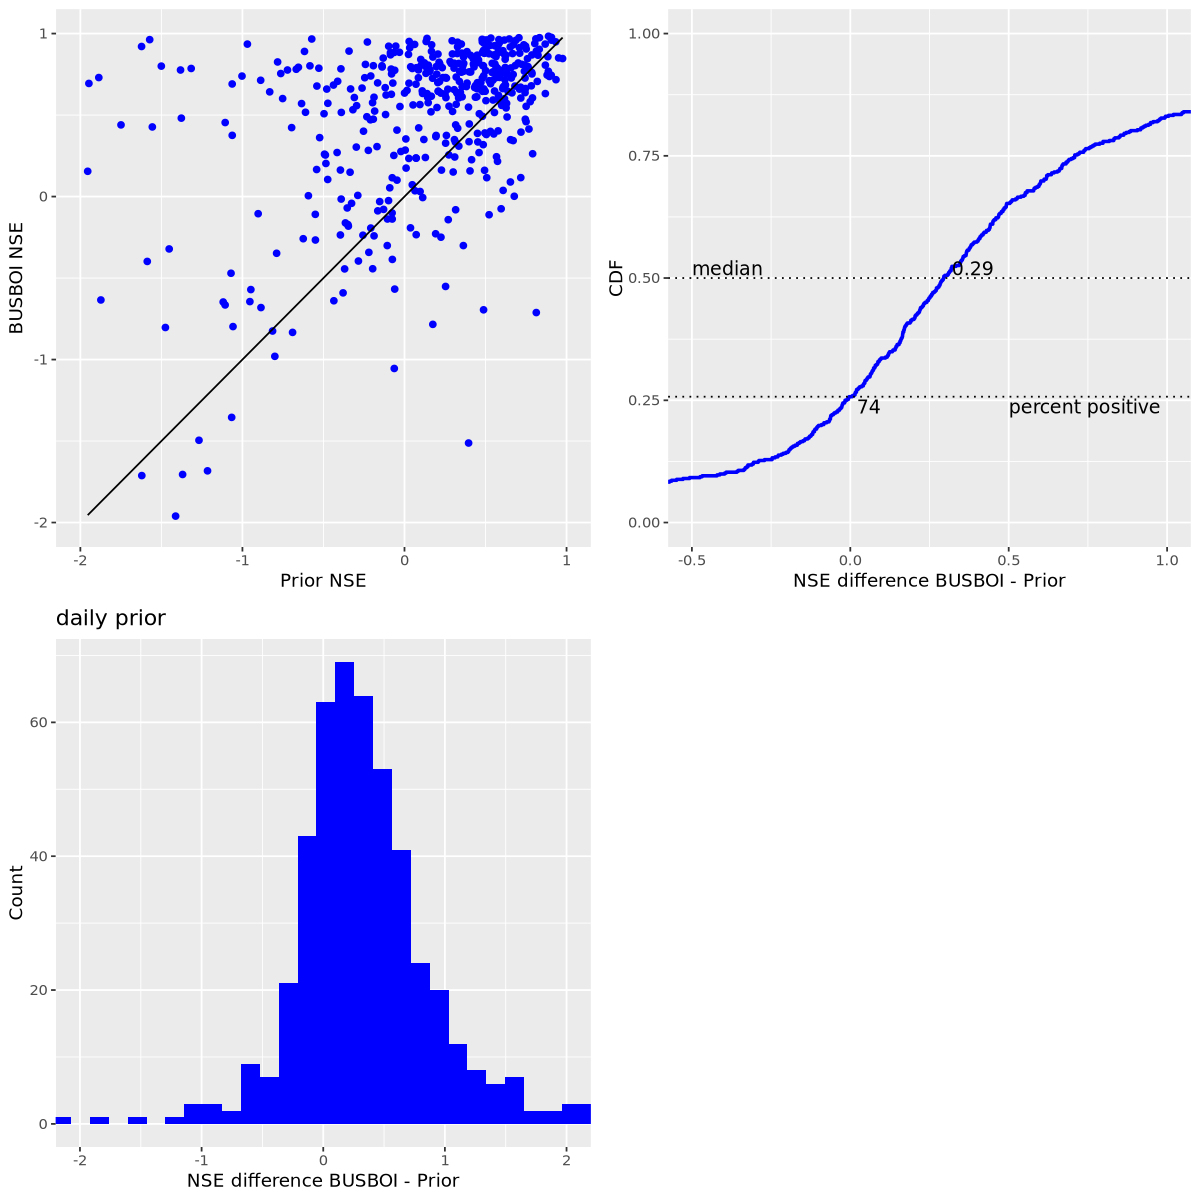

In [102]:
daily_prior=filter(busboi_daily,ID2=='prior')%>%
    transmute(reach_id=reach_id,prior_NSE=NSE)

daily_algo=filter(busboi_daily,ID2=='algo')%>%
    transmute(reach_id=reach_id,algo_NSE=NSE)

daily_difference=left_join(daily_prior,daily_algo,by='reach_id')%>%
    mutate(delta_NSE=algo_NSE-prior_NSE)%>%
    filter(algo_NSE>-100)

p3=ggplot(daily_difference)+
    geom_point(aes(x=prior_NSE,y=algo_NSE),col=palette[2])+
    geom_line(aes(x=prior_NSE,y=prior_NSE),col='black')+
    xlim(c(-15,1))+
    ylim(c(-15,1))

p4=ggplot(daily_difference)+
    geom_point(aes(x=prior_NSE,y=algo_NSE),col=palette[2])+
    geom_line(aes(x=prior_NSE,y=prior_NSE),col='black')+
    xlim(c(-2,1))+
    ylim(c(-2,1))+
    labs(x= 'Prior NSE')+
    labs(y= 'BUSBOI NSE')

#caclulate percent positive, 1- for CDF
percPos= 1-(sum(daily_difference$delta_NSE >0) /length(daily_difference$delta_NSE))

p5=ggplot(daily_difference)+
    stat_ecdf(aes(x=delta_NSE),lwd=1,col=palette[2])+
  coord_cartesian(xlim=c(-0.5,1))+
    labs(x= 'NSE difference BUSBOI - Prior')+
    labs(y= 'CDF')+
    # annotate("text",hjust=0, x = 0.03+round(quantile(difference$delta_NSE,probs=0.32),digits=2), y = 0.34, label = round(quantile(difference$delta_NSE,probs=0.32),digits=2),
    #          size = 4)+
    annotate("text",hjust=0, x = 0.03+round(quantile(daily_difference$delta_NSE,probs=0.50),digits=2), 
             y = 0.52, label = round(quantile(daily_difference$delta_NSE,probs=0.50),digits=2),
             size = 4)+

    annotate("text",hjust=0, x = -0.5, y = 0.52, label ='median',
             size = 4)+
    annotate("text",hjust=0, x = 0.02, y = percPos-0.02, label =100*( 1-round(percPos,digits=2)),
             size = 4)+
   annotate("text",hjust=0, x =0.5 , y = percPos-0.02, label = 'percent positive',
             size = 4)+
    # geom_hline(yintercept = 0.32, linetype = "dotted", color = "black") +
    geom_hline(yintercept = 0.50, linetype = "dotted", color = "black") +
    geom_hline(yintercept = percPos, linetype = "dotted", color = "black") 

p6=ggplot(daily_difference)+
    geom_histogram(aes(x=delta_NSE),bins=6000,fill=palette[2])+
    coord_cartesian(xlim=c(-2,2))+
    labs(x= 'NSE difference BUSBOI - Prior')+
    labs(y= 'Count')+
    ggtitle('daily prior')

library(gridExtra)

options(repr.plot.width =10, repr.plot.height = 10)
suppressWarnings({
# grid.arrange(p4, p5, p6,nrow = 2)
    })
# p6
# p4
# p5

test=grid.arrange(p4, p5, p6,nrow = 2)
ggsave('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/Figures/daily_improvement.png',test)

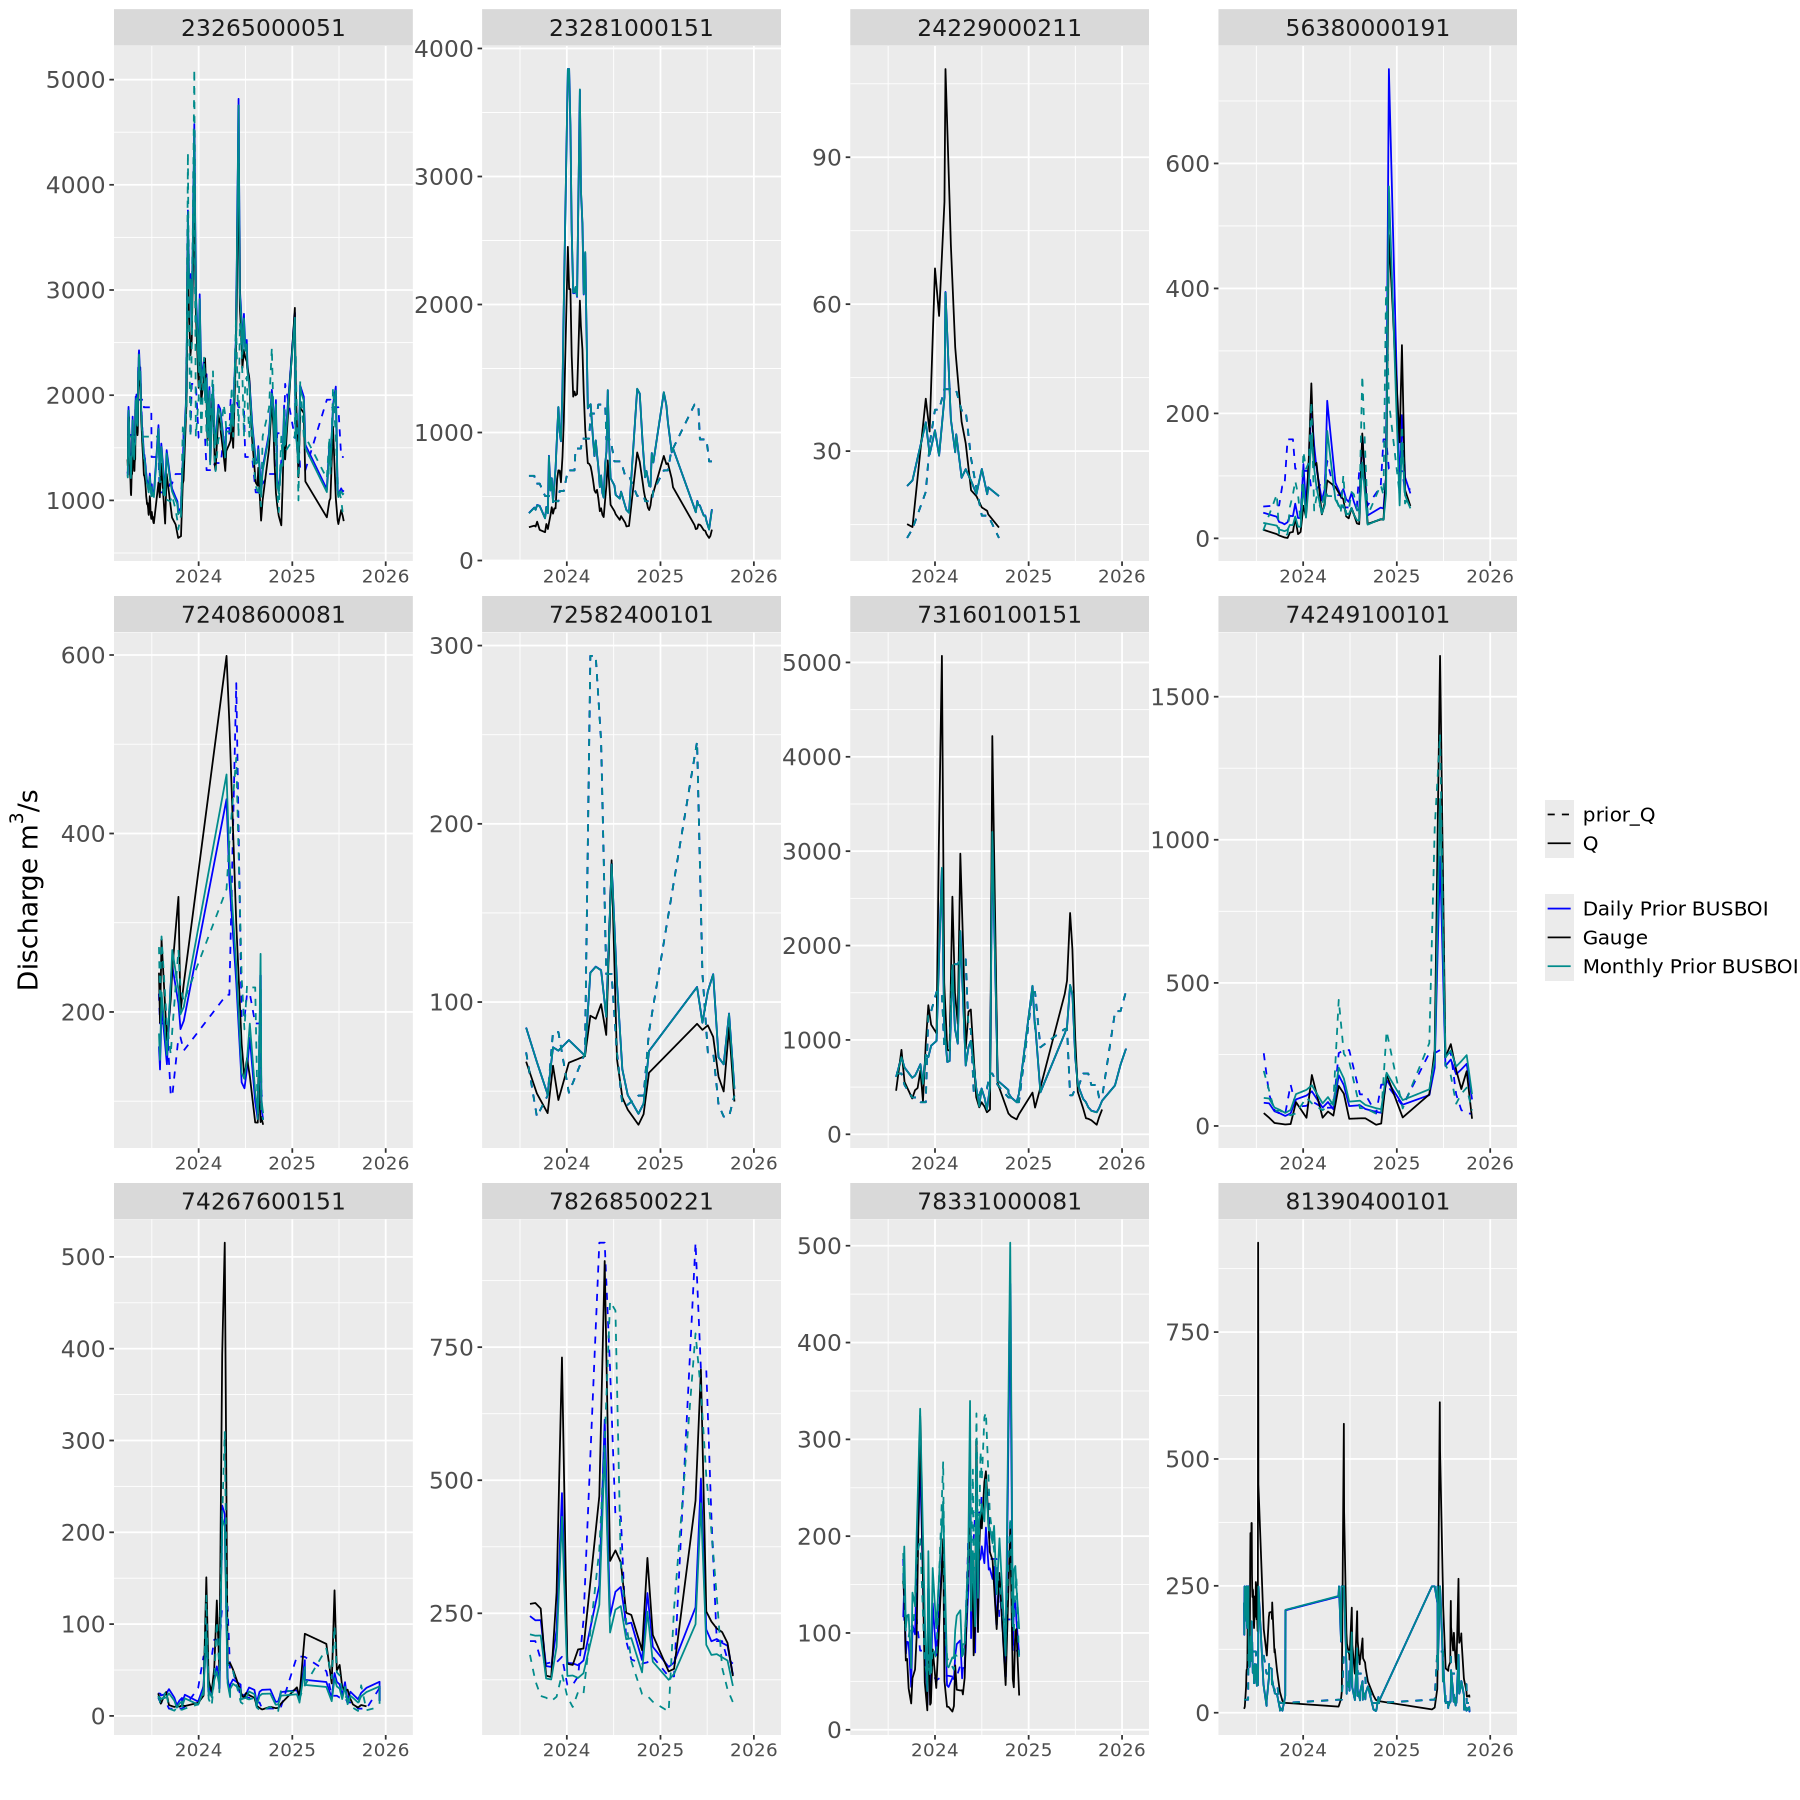

In [103]:
# busboi_Q1='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/monthly_b_then_Q/'
# busboi_Q2='/nas/cee-water/cjgleason/colin/BUSBOI/debug tests/bed_then_Q/'

suppressWarnings({
     hydro11=read_busboi(busboi_Q1,SVS_df,n_pairs,'SVS')$hydrograph%>%
         mutate(ID='Daily Prior BUSBOI')%>%
         distinct()
     
     hydro12=read_busboi(busboi_Q2,SVS_df,n_pairs,'SVS')$hydrograph%>%
         mutate(ID='Monthly Prior BUSBOI')%>%
         distinct()

     # reach_id_daily= unique(daily_hydro12$reach_id)
     min_swot=min(hydro12$date,na.rm=TRUE)
     max_swot=max(hydro12$date,na.rm=TRUE)

     SVS_plot=SVS_df%>%
         mutate(ID='Gauge')%>%
         mutate(Q=gauge_Q)%>%
         filter(Q>0)%>%
         select(-gauge_Q)%>%
         mutate(prior_Q=NA)%>%
         distinct()


hydrographer=rbind(hydro11,hydro12,SVS_plot)%>%
    gather( source,flow, -reach_id,-date,-ID)%>%
    left_join(difference, by='reach_id')%>%
    #bounds errors reomval for visualization
    filter(delta_NSE>-1)%>%
    filter(!is.na(flow))%>%
     #only plot places with all groups
      group_by(reach_id,date)%>%
     distinct()%>%
    mutate(n_hydrographs=n()) %>%
ungroup()%>%
    group_by(reach_id)%>%
    mutate(n_obs=n_distinct(date))%>%

    filter(n_obs>20)%>%
     ungroup()%>%
       filter (n_hydrographs>=5) %>%
       filter(reach_id %in% (sample(unique(reach_id),12,replace=FALSE)))

# 

p2=ggplot(hydrographer)+
    geom_line(aes(x=date,y=flow,col=ID,linetype=source))+
    facet_wrap(vars(reach_id),scales='free')+
       scale_colour_manual(values=c(palette[2],'black',palette[3]))+
    scale_linetype_manual(values=c('dashed','solid'))+
    scale_x_date(limits = c(min_swot,max_swot))+
    
ylab(expression(paste('Discharge ',m^3,'/s')))+
xlab('')+
 theme(
    plot.title = element_text(size = 20),           # Plot title
    axis.title.x = element_text(size = 16),         # X axis title
    axis.title.y = element_text(size = 16),         # Y axis title
    axis.text.x = element_text(size = 11),          # X axis tick labels
    axis.text.y = element_text(size = 14),          # Y axis tick labels
    legend.title =  element_blank(),        # Legend title
    legend.text = element_text(size = 12),          # Legend item labels
    strip.text = element_text(size = 14)            # Facet labels
  )

options(repr.plot.width =15, repr.plot.height = 15)
p2
})
ggsave('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/Figures/hydrographs.png',p2,width=20,height=15,units="in")


In [104]:
initial_bed=readRDS('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/channel_examples/73180400011initial_channel.rds')
final_bed=readRDS('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/channel_examples/73180400011final_channel.rds')

Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_point()`).”


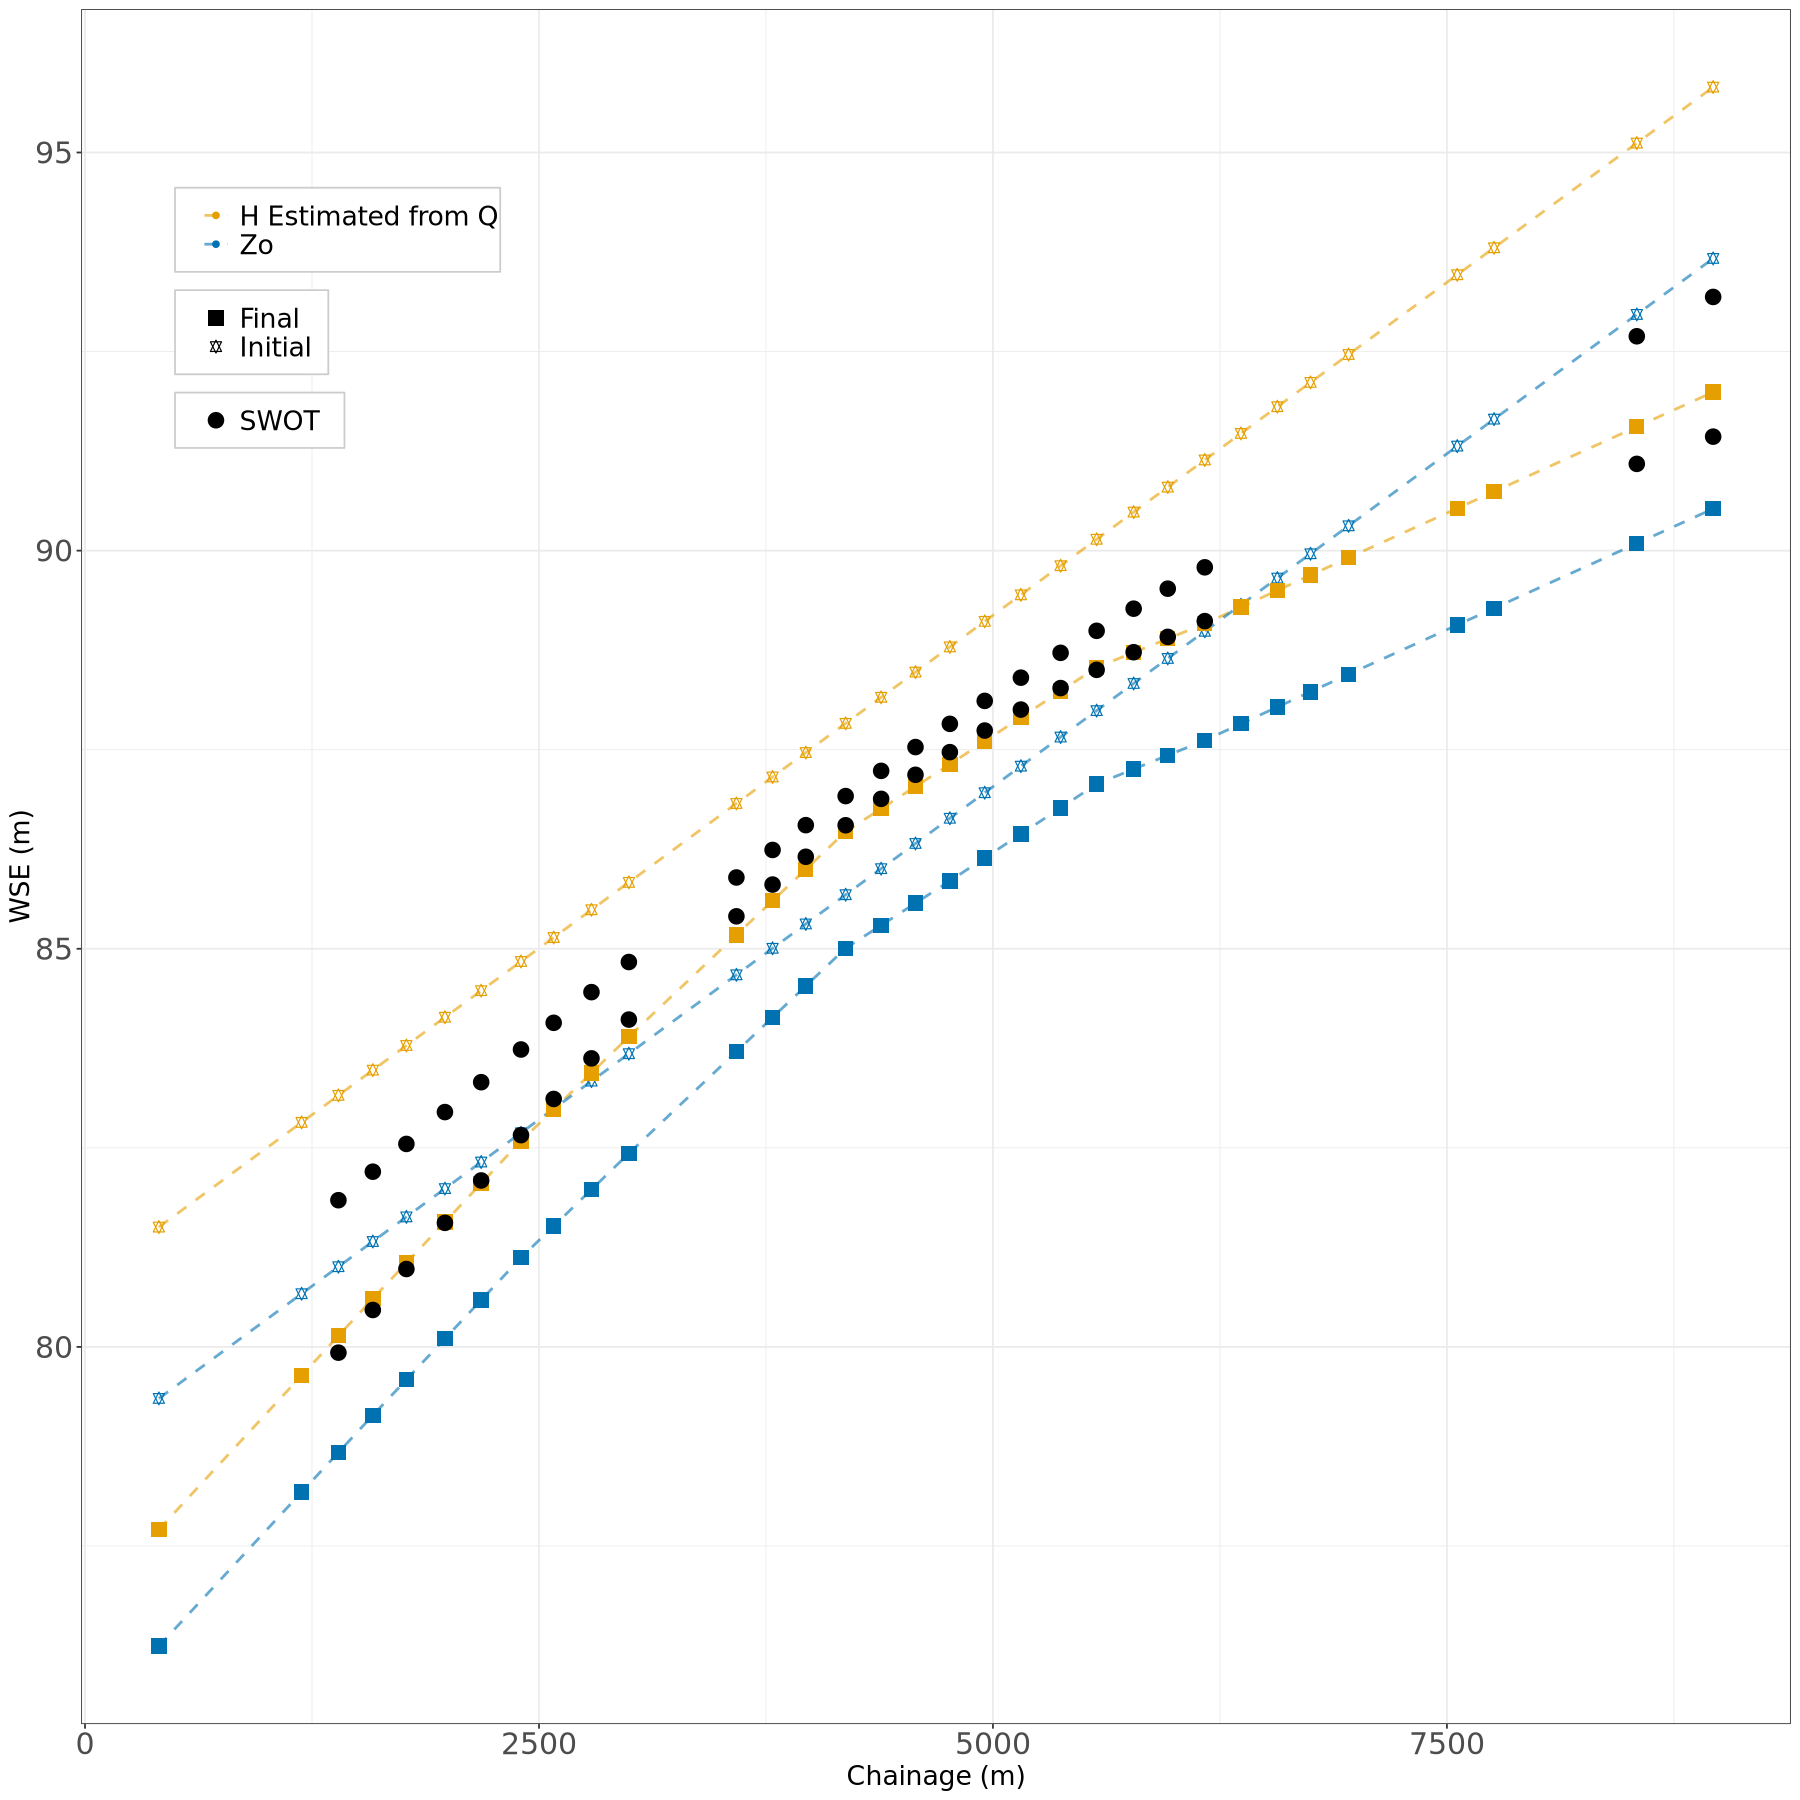

In [105]:
random_index=sample(length(initial_bed),1)
initial=initial_bed[[random_index]]%>%
    mutate(ID='Initial')
final=final_bed[[random_index]]%>%
    mutate(ID='Final')

plotter=rbind(initial,final)
plotter$source[plotter$source=='Estimated']='H Estimated from Q'
plotter$source[plotter$source=='Zo_ds']='Zo'

p12 = ggplot(plotter) +
    # non-SWOT connecting lines
    geom_line(data = filter(plotter, source != 'SWOT'),
              aes(x = new_x, y = height, group = interaction(ID, source), color = source),
              linewidth = 0.8, linetype = 'dashed', alpha = 0.6) +
    # non-SWOT points
    geom_point(data = filter(plotter, source != 'SWOT'),
           aes(x = new_x, y = height, color = source, shape = ID, size = ID)) +
    scale_size_manual(values = c(4, 2)) +  # square stays 4, star shrinks to 3
   guides(
    size  = 'none',
    shape = guide_legend(override.aes = list(size = c(4, 2)))   )+
    # SWOT points — rendered last so they sit on top
    geom_point(data = filter(plotter, source == 'SWOT'),
               aes(x = new_x, y = height, fill = 'SWOT'),
               color = 'black', shape = 21, size = 4) +
    scale_color_manual(values = c('#E69F00', '#0072B2'))+
    scale_fill_manual(values = c('SWOT' = 'black')) +
    scale_shape_manual(values = c(15, 11)) +


    labs(x = 'Chainage (m)', y = 'WSE (m)', color = NULL, shape = NULL, fill = NULL) +
    theme_bw() +
    theme(
        axis.text  = element_text(size = 18),
        axis.title = element_text(size = 16),
        legend.position       = c(0.15, 0.82),
        legend.background     = element_rect(fill = "white", color = "grey80"),
        legend.margin         = margin(8, 16, 8, 16),
        legend.key.size       = unit(1.2, 'lines'),
        legend.title          = element_text(size = 12),
        legend.text           = element_text(size = 16)
    )
p12

# ggsave('/nas/cee-water/cjgleason/colin/BUSBOI/BUSBOI/Figures/channel_solution.png',
#        p12, width = 20, height = 15, units = "in", dpi = 150, scale = 0.5)